<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/(Analysis)Spatial_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Spatial Accuracy Summary ###
         Condition TargetForce  IsCorrect
0           In-air        0.6g   0.888889
1           In-air        1.4g   1.000000
2  On-touch (Hard)        0.6g   1.000000
3  On-touch (Hard)        1.4g   0.888889


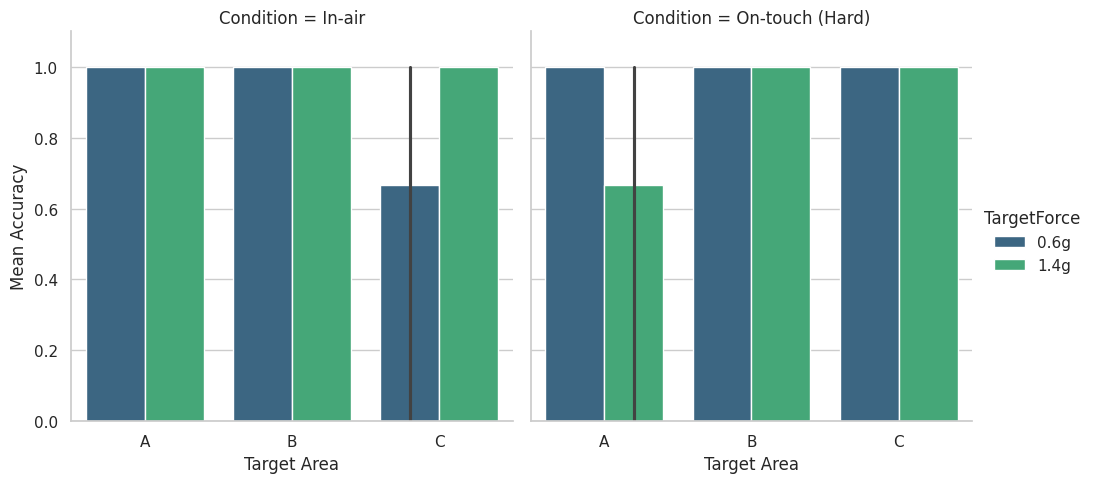

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. 데이터 로드
df_spatial = pd.read_csv('P2_Exp3_SpatialDiscrimination.csv')
df_spatial['IsCorrect'] = df_spatial['IsCorrect'].astype(int)

# 2. 조건 및 강도별 정확도 요약 출력
summary = df_spatial.groupby(['Condition', 'TargetForce'])['IsCorrect'].mean().reset_index()
print("### Spatial Accuracy Summary ###")
print(summary)

# 3. 정확도 시각화 (Area & Force)
sns.set_theme(style="whitegrid")
g = sns.catplot(data=df_spatial, x='TargetArea', y='IsCorrect', hue='TargetForce',
                col='Condition', kind='bar', order=['A', 'B', 'C'], palette='viridis')
g.set_axis_labels("Target Area", "Mean Accuracy")
g.set(ylim=(0, 1.1))
plt.show()

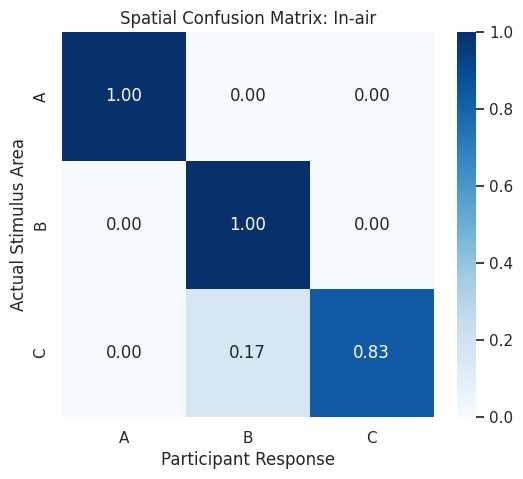

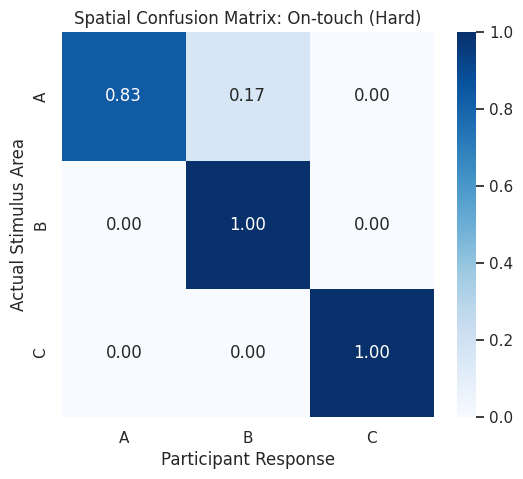

In [6]:
def plot_spatial_confusion(condition_name):
    cond_df = df_spatial[df_spatial['Condition'] == condition_name]
    labels = ['A', 'B', 'C']

    # 혼동 행렬 생성 및 정규화
    cm = confusion_matrix(cond_df['TargetArea'], cond_df['UserChoice'], labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Spatial Confusion Matrix: {condition_name}')
    plt.ylabel('Actual Stimulus Area')
    plt.xlabel('Participant Response')
    plt.show()

# 각 조건별로 히트맵 출력
for cond in df_spatial['Condition'].unique():
    plot_spatial_confusion(cond)